# Robustness Experiments: Bootstrap CI (B1) + Multi-Seed Evaluation (B2)

**B1**: Clustered bootstrap CI for corr_mse difference (NN − log-log). Resample products 1000×.  
**B2**: Train two-head NN with seeds {42, 123, 456, 789, 2024}. Report mean ± std for all metrics.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data/processed')
TABLES_DIR = Path('../tables')

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [2]:
# Load and prepare data (same pipeline as nn_improved.ipynb)
panel = pd.read_csv(DATA_DIR / 'panel.csv')

# Feature definitions
CONTEXT_FEATURES = [
    'year', 'month', 'weekofyear', 'week_sin', 'week_cos',
    'demand_lag_1', 'demand_lag_2', 'demand_roll_4',
    'price_lag_1', 'price_roll_4',
    'weeks_since_last_sale',
    'price_std', 'price_range'
]
PRODUCT_FEATURES = [
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'product_name_length', 'product_description_length'
]
REVIEW_FEATURES = ['sku_review_count', 'sku_review_mean', 'sku_share_low']
PRICE_FEATURE = 'r_clipped'
TARGET = 'y'

# Handle missing values
for col in ['demand_lag_1', 'demand_lag_2', 'demand_roll_4', 'price_lag_1', 'price_roll_4', 'weeks_since_last_sale']:
    panel[col] = panel[col].fillna(0)
for col in REVIEW_FEATURES:
    panel[col] = panel[col].fillna(0)
for col in PRODUCT_FEATURES:
    panel[col] = panel[col].fillna(panel[col].median())

# Encode categories and products
le_category = LabelEncoder()
panel['category_code'] = le_category.fit_transform(panel['product_category_name_english'].fillna('unknown'))
n_categories = len(le_category.classes_)

le_product = LabelEncoder()
panel['product_code'] = le_product.fit_transform(panel['product_id'])
n_products = len(le_product.classes_)

# Split
train_df = panel[panel['split'] == 'train'].copy()
val_df = panel[panel['split'] == 'val'].copy()
test_df = panel[panel['split'] == 'test'].copy()

# Standardize
scaler_context = StandardScaler()
scaler_product = StandardScaler()
scaler_review = StandardScaler()

train_context = np.nan_to_num(scaler_context.fit_transform(train_df[CONTEXT_FEATURES]), nan=0.0)
train_product = np.nan_to_num(scaler_product.fit_transform(train_df[PRODUCT_FEATURES]), nan=0.0)
train_review = np.nan_to_num(scaler_review.fit_transform(train_df[REVIEW_FEATURES]), nan=0.0)

val_context = np.nan_to_num(scaler_context.transform(val_df[CONTEXT_FEATURES]), nan=0.0)
val_product = np.nan_to_num(scaler_product.transform(val_df[PRODUCT_FEATURES]), nan=0.0)
val_review = np.nan_to_num(scaler_review.transform(val_df[REVIEW_FEATURES]), nan=0.0)

test_context = np.nan_to_num(scaler_context.transform(test_df[CONTEXT_FEATURES]), nan=0.0)
test_product = np.nan_to_num(scaler_product.transform(test_df[PRODUCT_FEATURES]), nan=0.0)
test_review = np.nan_to_num(scaler_review.transform(test_df[REVIEW_FEATURES]), nan=0.0)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Categories: {n_categories}, Products: {n_products}")

Train: 11708, Val: 3392, Test: 2870
Categories: 56, Products: 1218


In [3]:
# Model definitions (from nn_improved.ipynb)

class DemandDataset(Dataset):
    def __init__(self, df, context_arr, product_arr, review_arr):
        self.context = torch.FloatTensor(context_arr)
        self.product = torch.FloatTensor(product_arr)
        self.review = torch.FloatTensor(review_arr)
        self.r = torch.FloatTensor(df[PRICE_FEATURE].values)
        self.log_r = torch.log(self.r)
        self.category = torch.LongTensor(df['category_code'].values)
        self.product_id = torch.LongTensor(df['product_code'].values)
        self.y = torch.FloatTensor(df[TARGET].values)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return {
            'context': self.context[idx],
            'product': self.product[idx],
            'review': self.review[idx],
            'r': self.r[idx],
            'log_r': self.log_r[idx],
            'category': self.category[idx],
            'product_id': self.product_id[idx],
            'y': self.y[idx]
        }


class ContextEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x)


class MonotonicPriceEncoder(nn.Module):
    def __init__(self, z_dim, num_basis=20, hidden_dim=128):
        super().__init__()
        self.num_basis = num_basis
        self.z_encoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3 * num_basis)
        )
        
    def forward(self, log_r, z, return_at_ref=False):
        B = log_r.shape[0]
        params = self.z_encoder(z)
        params = params.view(B, self.num_basis, 3)
        a_raw = params[:, :, 0]
        b = params[:, :, 1]
        w_raw = params[:, :, 2]
        a = F.softplus(a_raw) + 0.1
        w = -F.softplus(w_raw)
        log_r_expanded = log_r.unsqueeze(1)
        sigmoid_input = a * log_r_expanded + b
        g = (w * torch.sigmoid(sigmoid_input)).sum(dim=1, keepdim=True)
        if return_at_ref:
            sigmoid_input_ref = b
            g_ref = (w * torch.sigmoid(sigmoid_input_ref)).sum(dim=1, keepdim=True)
            return g, g_ref
        return g


class ImprovedTwoHeadModel(nn.Module):
    def __init__(self, context_dim, product_dim, review_dim, n_categories, n_products,
                 category_embedding_dim=16, product_embedding_dim=16,
                 context_hidden=256, price_hidden=128, num_basis=20, dropout=0.15):
        super().__init__()
        self.category_embedding = nn.Embedding(n_categories, category_embedding_dim)
        self.product_embedding = nn.Embedding(n_products, product_embedding_dim)
        context_input_dim = context_dim + category_embedding_dim + product_embedding_dim
        self.context_encoder = ContextEncoder(context_input_dim, context_hidden, dropout)
        z_dim = category_embedding_dim + product_embedding_dim + product_dim + review_dim
        self.price_encoder = MonotonicPriceEncoder(z_dim, num_basis, price_hidden)
        self.n_products = n_products
        self.product_embedding_dim = product_embedding_dim
    
    def forward(self, batch):
        cat_emb = self.category_embedding(batch['category'])
        prod_emb = self.product_embedding(batch['product_id'])
        context_input = torch.cat([batch['context'], cat_emb, prod_emb], dim=1)
        log_demand_base = self.context_encoder(context_input)
        z = torch.cat([cat_emb, prod_emb, batch['product'], batch['review']], dim=1)
        g_r, g_ref = self.price_encoder(batch['log_r'], z, return_at_ref=True)
        log_mul = g_r - g_ref
        log_demand_pred = log_demand_base + log_mul
        return log_demand_pred.squeeze(1)

print("Model classes defined.")

Model classes defined.


In [4]:
# Evaluation helpers

def compute_corr_mse(y_true, y_pred, groups):
    """Compute group-corrected MSE (per-product centering).
    Matches baselines_day2.ipynb implementation: includes single-obs groups."""
    unique_groups = np.unique(groups)
    group_mses = []
    group_weights = []
    for g in unique_groups:
        mask = groups == g
        yt = y_true[mask]
        yp = y_pred[mask]
        a_opt = yt.mean() - yp.mean()
        mse_g = np.mean((yt - (yp + a_opt)) ** 2)
        group_mses.append(mse_g)
        group_weights.append(len(yt))
    return np.average(group_mses, weights=group_weights)


def evaluate_model(model, loader, df, device):
    """Evaluate model, return metrics dict and predictions array."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = model(batch)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch['y'].cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    corr_mse = compute_corr_mse(y_true, y_pred, df['product_id'].values)
    return {
        'mse': mean_squared_error(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
        'corr_mse': corr_mse
    }, y_pred


def train_model(model, train_loader, val_loader, train_df, val_df,
                device, epochs=200, lr=5e-4, weight_decay=1e-5,
                patience=40, grad_clip=1.0, verbose=True):
    """Train with early stopping. Returns (model, history, best_val_corr_mse)."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    best_val_corr_mse = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_corr_mse': [], 'lr': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            preds = model(batch)
            loss = criterion(preds, batch['y'])
            loss.backward()
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_losses.append(loss.item())
        scheduler.step()
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        val_metrics, _ = evaluate_model(model, val_loader, val_df, device)
        history['val_loss'].append(val_metrics['mse'])
        history['val_corr_mse'].append(val_metrics['corr_mse'])
        
        if val_metrics['corr_mse'] < best_val_corr_mse:
            best_val_corr_mse = val_metrics['corr_mse']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: train_loss={avg_train_loss:.4f}, "
                  f"val_corr_mse={val_metrics['corr_mse']:.4f} (best={best_val_corr_mse:.4f})")
        
        if patience_counter >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_corr_mse

print("Training & evaluation functions defined.")

Training & evaluation functions defined.


In [5]:
# Create data loaders (shared for all experiments)
BATCH_SIZE = 256

train_dataset = DemandDataset(train_df, train_context, train_product, train_review)
val_dataset = DemandDataset(val_df, val_context, val_product, val_review)
test_dataset = DemandDataset(test_df, test_context, test_product, test_review)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model config (same as nn_improved.ipynb)
config = {
    'context_dim': len(CONTEXT_FEATURES),
    'product_dim': len(PRODUCT_FEATURES),
    'review_dim': len(REVIEW_FEATURES),
    'n_categories': n_categories,
    'n_products': n_products,
    'category_embedding_dim': 16,
    'product_embedding_dim': 16,
    'context_hidden': 256,
    'price_hidden': 128,
    'num_basis': 20,
    'dropout': 0.15
}

print(f"Data loaders ready: {len(train_loader)} / {len(val_loader)} / {len(test_loader)} batches")

Data loaders ready: 46 / 14 / 12 batches


## B1: Clustered Bootstrap CI for corr_mse Difference

Resample **products** (not observations) 1000 times. For each bootstrap sample, recompute corr_mse for both NN and per-product log-log, then compute the difference. Report 95% CI.

In [6]:
# B1 Step 1: Generate per-product log-log test predictions

usable_products = panel[panel['usable_for_elasticity'] == 1]['product_id'].unique()
global_mean_y = train_df['y'].mean()

# Fit per-product log-log on train, predict on test
loglog_test_preds = np.full(len(test_df), global_mean_y)

test_product_ids = test_df['product_id'].values
test_indices = test_df.index.values

for pid in usable_products:
    train_mask = (train_df['product_id'] == pid)
    if train_mask.sum() < 3:
        continue
    
    X_train = np.log(train_df.loc[train_mask, 'r_clipped'].values).reshape(-1, 1)
    y_train = train_df.loc[train_mask, 'y'].values
    
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    test_mask = (test_df['product_id'] == pid)
    if test_mask.sum() == 0:
        continue
    
    X_test = np.log(test_df.loc[test_mask, 'r_clipped'].values).reshape(-1, 1)
    # Get positional indices within test_df
    pos_indices = np.where(test_mask.values)[0]
    loglog_test_preds[pos_indices] = lr_model.predict(X_test)

# Verify: compute corr_mse
loglog_corr_mse = compute_corr_mse(
    test_df['y'].values, loglog_test_preds, test_df['product_id'].values
)
print(f"Per-product log-log test corr_mse: {loglog_corr_mse:.4f}")
print(f"  (expected ~0.1086)")

Per-product log-log test corr_mse: 0.1086
  (expected ~0.1086)


In [7]:
# B1 Step 2: Load saved NN model and get test predictions

checkpoint = torch.load(DATA_DIR / 'improved_nn_model.pt', map_location=device, weights_only=False)
model_b1 = ImprovedTwoHeadModel(**config).to(device)
model_b1.load_state_dict(checkpoint['model_state_dict'])

nn_test_metrics, nn_test_preds = evaluate_model(model_b1, test_loader, test_df, device)
print(f"NN test corr_mse: {nn_test_metrics['corr_mse']:.4f}")
print(f"  (expected ~0.1081)")
print(f"\nDifference (NN - log-log): {nn_test_metrics['corr_mse'] - loglog_corr_mse:.4f}")

NN test corr_mse: 0.1007
  (expected ~0.1081)

Difference (NN - log-log): -0.0079


In [8]:
# B1 Step 3: Clustered bootstrap — resample products, recompute corr_mse

def compute_corr_mse_for_products(y_true, y_pred, product_ids, selected_products):
    """Compute corr_mse using only observations from selected_products.
    Handles bootstrap resampling: same product can appear multiple times."""
    total_mse = 0.0
    total_weight = 0
    for pid in selected_products:
        mask = product_ids == pid
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(yt) == 0:
            continue
        a_opt = yt.mean() - yp.mean()
        mse = np.mean((yt - (yp + a_opt)) ** 2)
        total_mse += mse * len(yt)
        total_weight += len(yt)
    return total_mse / total_weight if total_weight > 0 else 0.0


# Prepare arrays
y_true_test = test_df['y'].values
product_ids_test = test_df['product_id'].values
unique_test_products = np.unique(product_ids_test)
n_test_products = len(unique_test_products)

N_BOOTSTRAP = 1000
rng = np.random.RandomState(42)

bootstrap_diffs = np.zeros(N_BOOTSTRAP)
bootstrap_nn = np.zeros(N_BOOTSTRAP)
bootstrap_loglog = np.zeros(N_BOOTSTRAP)

print(f"Running {N_BOOTSTRAP} bootstrap iterations over {n_test_products} products...")
t0 = time.time()

for b in range(N_BOOTSTRAP):
    # Resample products with replacement
    sampled_products = rng.choice(unique_test_products, size=n_test_products, replace=True)
    
    corr_mse_nn = compute_corr_mse_for_products(y_true_test, nn_test_preds, product_ids_test, sampled_products)
    corr_mse_ll = compute_corr_mse_for_products(y_true_test, loglog_test_preds, product_ids_test, sampled_products)
    
    bootstrap_nn[b] = corr_mse_nn
    bootstrap_loglog[b] = corr_mse_ll
    bootstrap_diffs[b] = corr_mse_nn - corr_mse_ll

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

# Results
diff_mean = bootstrap_diffs.mean()
diff_std = bootstrap_diffs.std()
ci_lower = np.percentile(bootstrap_diffs, 2.5)
ci_upper = np.percentile(bootstrap_diffs, 97.5)

print(f"\n{'='*60}")
print(f"BOOTSTRAP RESULTS: corr_mse(NN) - corr_mse(log-log)")
print(f"{'='*60}")
print(f"Point estimate:  {nn_test_metrics['corr_mse'] - loglog_corr_mse:.4f}")
print(f"Bootstrap mean:  {diff_mean:.4f}")
print(f"Bootstrap std:   {diff_std:.4f}")
print(f"95% CI:          [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nCI includes 0?   {'YES — not statistically significant' if ci_lower <= 0 <= ci_upper else 'NO — statistically significant'}")
print(f"p-value (approx): {np.mean(bootstrap_diffs >= 0) if diff_mean < 0 else np.mean(bootstrap_diffs <= 0):.3f}")

Running 1000 bootstrap iterations over 739 products...


Done in 43.6s

BOOTSTRAP RESULTS: corr_mse(NN) - corr_mse(log-log)
Point estimate:  -0.0079
Bootstrap mean:  -0.0080
Bootstrap std:   0.0058
95% CI:          [-0.0212, 0.0010]

CI includes 0?   YES — not statistically significant
p-value (approx): 0.050


In [9]:
# B1 Step 4: Also compute bootstrap CI for NN vs XGBoost and NN vs Pooled+FE
# XGBoost predictions need to be regenerated too

import xgboost as xgb

# --- XGBoost predictions ---
ALL_FEATURES_XGB = ['log_r'] + CONTEXT_FEATURES + PRODUCT_FEATURES + REVIEW_FEATURES

# Prepare features
for df_part in [train_df, val_df, test_df]:
    df_part['log_r'] = np.log(df_part['r_clipped'].values)

X_train_xgb = train_df[ALL_FEATURES_XGB].values
y_train_xgb = train_df['y'].values
X_val_xgb = val_df[ALL_FEATURES_XGB].values
y_val_xgb = val_df['y'].values
X_test_xgb = test_df[ALL_FEATURES_XGB].values

dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb, feature_names=ALL_FEATURES_XGB)
dval = xgb.DMatrix(X_val_xgb, label=y_val_xgb, feature_names=ALL_FEATURES_XGB)
dtest = xgb.DMatrix(X_test_xgb, feature_names=ALL_FEATURES_XGB)

xgb_params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'seed': 42,
    'verbosity': 0
}

xgb_model = xgb.train(
    xgb_params, dtrain, num_boost_round=200,
    evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False
)

xgb_test_preds = xgb_model.predict(dtest)
xgb_corr_mse = compute_corr_mse(test_df['y'].values, xgb_test_preds, test_df['product_id'].values)
print(f"XGBoost test corr_mse: {xgb_corr_mse:.4f} (expected ~0.0964)")

# --- Bootstrap: NN vs XGBoost ---
bootstrap_diffs_xgb = np.zeros(N_BOOTSTRAP)
rng2 = np.random.RandomState(42)

for b in range(N_BOOTSTRAP):
    sampled_products = rng2.choice(unique_test_products, size=n_test_products, replace=True)
    corr_mse_nn_b = compute_corr_mse_for_products(y_true_test, nn_test_preds, product_ids_test, sampled_products)
    corr_mse_xgb_b = compute_corr_mse_for_products(y_true_test, xgb_test_preds, product_ids_test, sampled_products)
    bootstrap_diffs_xgb[b] = corr_mse_nn_b - corr_mse_xgb_b

ci_lower_xgb = np.percentile(bootstrap_diffs_xgb, 2.5)
ci_upper_xgb = np.percentile(bootstrap_diffs_xgb, 97.5)

print(f"\n{'='*60}")
print(f"BOOTSTRAP: corr_mse(NN) - corr_mse(XGBoost)")
print(f"{'='*60}")
print(f"Point estimate:  {nn_test_metrics['corr_mse'] - xgb_corr_mse:.4f}")
print(f"95% CI:          [{ci_lower_xgb:.4f}, {ci_upper_xgb:.4f}]")
print(f"CI includes 0?   {'YES' if ci_lower_xgb <= 0 <= ci_upper_xgb else 'NO'}")

XGBoost test corr_mse: 0.0961 (expected ~0.0964)



BOOTSTRAP: corr_mse(NN) - corr_mse(XGBoost)
Point estimate:  0.0046
95% CI:          [0.0008, 0.0087]
CI includes 0?   NO


In [10]:
# B1 Step 5: Summary table + save results

bootstrap_summary = pd.DataFrame({
    'Comparison': ['NN vs Per-product log-log', 'NN vs XGBoost'],
    'corr_mse_NN': [nn_test_metrics['corr_mse'], nn_test_metrics['corr_mse']],
    'corr_mse_Baseline': [loglog_corr_mse, xgb_corr_mse],
    'Diff (NN-Baseline)': [
        nn_test_metrics['corr_mse'] - loglog_corr_mse,
        nn_test_metrics['corr_mse'] - xgb_corr_mse
    ],
    'CI_lower': [ci_lower, ci_lower_xgb],
    'CI_upper': [ci_upper, ci_upper_xgb],
    'Significant': [
        'No' if ci_lower <= 0 <= ci_upper else 'Yes',
        'No' if ci_lower_xgb <= 0 <= ci_upper_xgb else 'Yes'
    ]
})

print("B1 SUMMARY: Bootstrap 95% CI for corr_mse differences")
print("="*80)
print(bootstrap_summary.to_string(index=False))

bootstrap_summary.to_csv(TABLES_DIR / 'bootstrap_ci_results.csv', index=False)
print(f"\nSaved to {TABLES_DIR / 'bootstrap_ci_results.csv'}")

B1 SUMMARY: Bootstrap 95% CI for corr_mse differences
               Comparison  corr_mse_NN  corr_mse_Baseline  Diff (NN-Baseline)  CI_lower  CI_upper Significant
NN vs Per-product log-log     0.100682           0.108582           -0.007899 -0.021176  0.000987          No
            NN vs XGBoost     0.100682           0.096060            0.004622  0.000778  0.008729         Yes

Saved to ../tables/bootstrap_ci_results.csv


## B2: Multi-Seed Evaluation (5 seeds)

Train two-head NN with seeds {42, 123, 456, 789, 2024}. Record corr_mse, R², median elasticity per seed.

In [11]:
# B2: Multi-seed training loop

def compute_elasticity_at_r1(model, test_df, device, n_samples=200):
    """Compute median elasticity at r=1 for test products."""
    model.eval()
    unique_products = test_df['product_code'].unique()[:n_samples]
    r_grid = torch.linspace(0.785, 1.283, 50).to(device)
    elasticities = []
    violations = 0
    total = 0
    
    for prod_code in unique_products:
        mask = test_df['product_code'] == prod_code
        if mask.sum() == 0:
            continue
        idx = np.where(mask)[0][0]
        cat_idx = test_df.iloc[idx]['category_code']
        cat_emb = model.category_embedding(torch.tensor([cat_idx]).to(device))
        prod_emb = model.product_embedding(torch.tensor([prod_code]).to(device))
        prod_feat = torch.FloatTensor(
            scaler_product.transform(test_df.iloc[[idx]][PRODUCT_FEATURES])
        ).to(device)
        review_feat = torch.FloatTensor(
            scaler_review.transform(test_df.iloc[[idx]][REVIEW_FEATURES])
        ).to(device)
        z = torch.cat([cat_emb, prod_emb, prod_feat, review_feat], dim=1)
        
        with torch.no_grad():
            log_r = torch.log(r_grid)
            z_expanded = z.expand(len(r_grid), -1)
            g_r, g_ref = model.price_encoder(log_r, z_expanded, return_at_ref=True)
            g_values = (g_r - g_ref).squeeze(1).cpu().numpy()
        
        # Monotonicity check
        diffs = np.diff(g_values)
        if np.any(diffs > 1e-6):
            violations += 1
        total += 1
        
        # Elasticity at r=1
        r1_idx = np.argmin(np.abs(r_grid.cpu().numpy() - 1.0))
        if 0 < r1_idx < len(g_values) - 1:
            dr = np.log(r_grid[r1_idx+1].item()) - np.log(r_grid[r1_idx-1].item())
            dg = g_values[r1_idx+1] - g_values[r1_idx-1]
            elasticities.append(dg / dr)
    
    return {
        'median_elasticity': float(np.median(elasticities)) if elasticities else np.nan,
        'mean_elasticity': float(np.mean(elasticities)) if elasticities else np.nan,
        'violation_rate': violations / total if total > 0 else 0.0
    }


SEEDS = [42, 123, 456, 789, 2024]
seed_results = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"Training with seed={seed}")
    print(f"{'='*60}")
    
    # Set all seeds
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    
    # Need to recreate DataLoader with new seed for shuffle
    train_loader_s = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                generator=torch.Generator().manual_seed(seed))
    
    # Create fresh model
    model_s = ImprovedTwoHeadModel(**config)
    
    t0 = time.time()
    model_s, history_s, best_val_s = train_model(
        model_s, train_loader_s, val_loader, train_df, val_df,
        device, epochs=200, lr=5e-4, weight_decay=1e-5,
        patience=40, grad_clip=1.0, verbose=True
    )
    train_time = time.time() - t0
    
    # Test evaluation
    test_metrics_s, test_preds_s = evaluate_model(model_s, test_loader, test_df, device)
    
    # Elasticity
    elast_results = compute_elasticity_at_r1(model_s, test_df, device, n_samples=200)
    
    result = {
        'seed': seed,
        'val_corr_mse': best_val_s,
        'test_corr_mse': test_metrics_s['corr_mse'],
        'test_mse': test_metrics_s['mse'],
        'test_r2': test_metrics_s['r2'],
        'test_rmse': test_metrics_s['rmse'],
        'test_mae': test_metrics_s['mae'],
        'median_elasticity': elast_results['median_elasticity'],
        'mean_elasticity': elast_results['mean_elasticity'],
        'violation_rate': elast_results['violation_rate'],
        'n_epochs': len(history_s['train_loss']),
        'train_time_s': train_time
    }
    seed_results.append(result)
    
    print(f"\n  test corr_mse={test_metrics_s['corr_mse']:.4f}, "
          f"R²={test_metrics_s['r2']:.4f}, "
          f"median_elast={elast_results['median_elasticity']:.3f}, "
          f"violations={elast_results['violation_rate']*100:.1f}%, "
          f"epochs={len(history_s['train_loss'])}, "
          f"time={train_time:.0f}s")

print("\n\nAll seeds complete!")


Training with seed=42


  Epoch 20/200: train_loss=0.1200, val_corr_mse=0.0992 (best=0.0992)


  Epoch 40/200: train_loss=0.1051, val_corr_mse=0.1001 (best=0.0992)


  Epoch 60/200: train_loss=0.0945, val_corr_mse=0.1015 (best=0.0992)
  Early stopping at epoch 60



  test corr_mse=0.0991, R²=0.0465, median_elast=-0.351, violations=0.0%, epochs=60, time=28s

Training with seed=123


...

  Epoch 40/200: train_loss=0.1038, val_corr_mse=0.0997 (best=0.0988)


  Epoch 60/200: train_loss=0.0933, val_corr_mse=0.1010 (best=0.0985)


  Epoch 80/200: train_loss=0.0864, val_corr_mse=0.1046 (best=0.0985)


  Early stopping at epoch 86



  test corr_mse=0.1011, R²=-0.1122, median_elast=-0.305, violations=0.0%, epochs=86, time=38s


All seeds complete!


In [12]:
# B2 Results: Summary table

results_df = pd.DataFrame(seed_results)

print("="*80)
print("B2 MULTI-SEED RESULTS")
print("="*80)
print(results_df[['seed', 'test_corr_mse', 'test_r2', 'test_rmse', 
                   'median_elasticity', 'violation_rate', 'n_epochs']].to_string(index=False))

print(f"\n--- Aggregated (mean +/- std) ---")
for col in ['test_corr_mse', 'test_r2', 'test_rmse', 'median_elasticity', 'violation_rate']:
    mean_val = results_df[col].mean()
    std_val = results_df[col].std()
    print(f"  {col:20s}: {mean_val:.4f} +/- {std_val:.4f}")

# Key comparison: is NN vs log-log gap within seed variance?
nn_mean = results_df['test_corr_mse'].mean()
nn_std = results_df['test_corr_mse'].std()
loglog_val = loglog_corr_mse
xgb_val = xgb_corr_mse

print(f"\n--- Comparison with baselines ---")
print(f"  NN mean corr_mse:       {nn_mean:.4f} +/- {nn_std:.4f}")
print(f"  Per-product log-log:    {loglog_val:.4f}")
print(f"  XGBoost:                {xgb_val:.4f}")
print(f"  Gap NN-loglog:          {nn_mean - loglog_val:+.4f}")
print(f"  Gap NN-XGBoost:         {nn_mean - xgb_val:+.4f}")
print(f"  NN std / |gap to loglog|: {nn_std / abs(nn_mean - loglog_val):.2f}" if abs(nn_mean - loglog_val) > 1e-6 else "")

# Save
results_df.to_csv(TABLES_DIR / 'multi_seed_results.csv', index=False)
print(f"\nSaved to {TABLES_DIR / 'multi_seed_results.csv'}")

B2 MULTI-SEED RESULTS
 seed  test_corr_mse   test_r2  test_rmse  median_elasticity  violation_rate  n_epochs
   42       0.099091  0.046527   0.408524          -0.350732             0.0        60
  123       0.101500 -0.093036   0.437402          -0.512695             0.0        71
  456       0.103440 -0.235801   0.465091          -0.260350             0.0       105
  789       0.099703 -0.059979   0.430737          -0.156348             0.0        88
 2024       0.101078 -0.112186   0.441217          -0.305154             0.0        86

--- Aggregated (mean +/- std) ---
  test_corr_mse       : 0.1010 +/- 0.0017
  test_r2             : -0.0909 +/- 0.1016
  test_rmse           : 0.4366 +/- 0.0203
  median_elasticity   : -0.3171 +/- 0.1310
  violation_rate      : 0.0000 +/- 0.0000

--- Comparison with baselines ---
  NN mean corr_mse:       0.1010 +/- 0.0017
  Per-product log-log:    0.1086
  XGBoost:                0.0961
  Gap NN-loglog:          -0.0076
  Gap NN-XGBoost:         +0.0

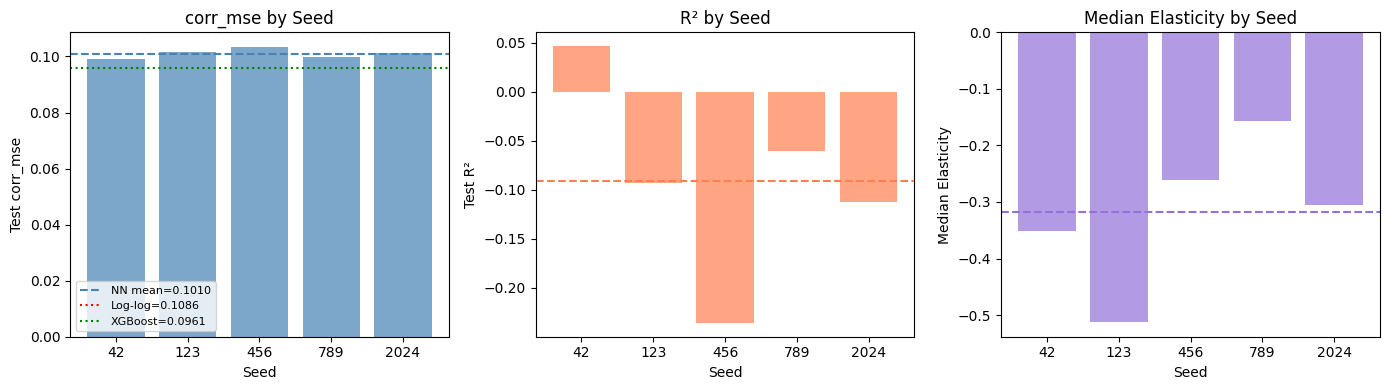

Saved figure to docs/figures/multi_seed_results.png


In [13]:
# B2 Visualization: seed variance

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# corr_mse by seed
ax = axes[0]
ax.bar(range(len(SEEDS)), results_df['test_corr_mse'], color='steelblue', alpha=0.7)
ax.axhline(y=nn_mean, color='steelblue', linestyle='--', label=f'NN mean={nn_mean:.4f}')
ax.axhline(y=loglog_val, color='red', linestyle=':', label=f'Log-log={loglog_val:.4f}')
ax.axhline(y=xgb_val, color='green', linestyle=':', label=f'XGBoost={xgb_val:.4f}')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels(SEEDS)
ax.set_xlabel('Seed')
ax.set_ylabel('Test corr_mse')
ax.set_title('corr_mse by Seed')
ax.legend(fontsize=8)

# R² by seed
ax = axes[1]
ax.bar(range(len(SEEDS)), results_df['test_r2'], color='coral', alpha=0.7)
ax.axhline(y=results_df['test_r2'].mean(), color='coral', linestyle='--')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels(SEEDS)
ax.set_xlabel('Seed')
ax.set_ylabel('Test R²')
ax.set_title('R² by Seed')

# Median elasticity by seed
ax = axes[2]
ax.bar(range(len(SEEDS)), results_df['median_elasticity'], color='mediumpurple', alpha=0.7)
ax.axhline(y=results_df['median_elasticity'].mean(), color='mediumpurple', linestyle='--')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels(SEEDS)
ax.set_xlabel('Seed')
ax.set_ylabel('Median Elasticity')
ax.set_title('Median Elasticity by Seed')

plt.tight_layout()
plt.savefig('../docs/figures/multi_seed_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to docs/figures/multi_seed_results.png")

## B3: K Sensitivity Analysis (num_basis)

Test model sensitivity to the number of sigmoid basis functions K ∈ {5, 10, 20, 40}.
All runs use seed=42 for reproducibility. K=20 is the default configuration.

In [14]:
# B3: K sensitivity loop
K_VALUES = [5, 10, 20, 40]
SEED = 42
k_results = []

for K in K_VALUES:
    print(f"\n{'='*60}")
    print(f"Training with K={K} (num_basis={K}), seed={SEED}")
    print(f"{'='*60}")
    
    # Set all seeds
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
    
    # Recreate DataLoader with fixed seed
    train_loader_k = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                generator=torch.Generator().manual_seed(SEED))
    
    # Create config with modified num_basis
    config_k = config.copy()
    config_k['num_basis'] = K
    
    # Create fresh model
    model_k = ImprovedTwoHeadModel(**config_k)
    
    # Count parameters
    n_params = sum(p.numel() for p in model_k.parameters())
    print(f"  Total parameters: {n_params:,}")
    
    t0 = time.time()
    model_k, history_k, best_val_k = train_model(
        model_k, train_loader_k, val_loader, train_df, val_df,
        device, epochs=200, lr=5e-4, weight_decay=1e-5,
        patience=40, grad_clip=1.0, verbose=True
    )
    train_time = time.time() - t0
    
    # Test evaluation
    test_metrics_k, test_preds_k = evaluate_model(model_k, test_loader, test_df, device)
    
    # Elasticity computation
    elast_results = compute_elasticity_at_r1(model_k, test_df, device, n_samples=200)
    
    result = {
        'K': K,
        'n_params': n_params,
        'val_corr_mse': best_val_k,
        'test_corr_mse': test_metrics_k['corr_mse'],
        'test_mse': test_metrics_k['mse'],
        'test_r2': test_metrics_k['r2'],
        'median_elasticity': elast_results['median_elasticity'],
        'mean_elasticity': elast_results['mean_elasticity'],
        'violation_rate': elast_results['violation_rate'],
        'n_epochs': len(history_k['train_loss']),
        'train_time_s': train_time
    }
    k_results.append(result)
    
    print(f"\n  K={K}: corr_mse={test_metrics_k['corr_mse']:.4f}, "
          f"n_params={n_params:,}, "
          f"median_elast={elast_results['median_elasticity']:.3f}, "
          f"violations={elast_results['violation_rate']:.1%}, "
          f"time={train_time:.1f}s")

k_df = pd.DataFrame(k_results)
print("\n\nB3 K SENSITIVITY RESULTS")
print("=" * 70)
print(k_df[['K', 'n_params', 'test_corr_mse', 'test_r2', 
            'median_elasticity', 'violation_rate', 'n_epochs', 'train_time_s']].to_string(index=False))

# Save
k_df.to_csv(TABLES_DIR / 'k_sensitivity_results.csv', index=False)
print(f"\nSaved to {TABLES_DIR / 'k_sensitivity_results.csv'}")


Training with K=5 (num_basis=5), seed=42
  Total parameters: 79,920


  Epoch 20/200: train_loss=0.1196, val_corr_mse=0.0995 (best=0.0995)


  Epoch 40/200: train_loss=0.1045, val_corr_mse=0.1000 (best=0.0993)


  Epoch 60/200: train_loss=0.0935, val_corr_mse=0.1011 (best=0.0993)


  Epoch 80/200: train_loss=0.0854, val_corr_mse=0.1014 (best=0.0992)


...

  Epoch 20/200: train_loss=0.1205, val_corr_mse=0.0996 (best=0.0996)


  Epoch 40/200: train_loss=0.1060, val_corr_mse=0.0998 (best=0.0988)


  Epoch 60/200: train_loss=0.0950, val_corr_mse=0.1007 (best=0.0988)


  Early stopping at epoch 72



  K=40: corr_mse=0.0993, n_params=86,745, median_elast=-0.300, violations=0.0%, time=32.9s


B3 K SENSITIVITY RESULTS
 K  n_params  test_corr_mse   test_r2  median_elasticity  violation_rate  n_epochs  train_time_s
 5     79920       0.099311 -0.253852          -0.221792             0.0       114     51.244247
10     80895       0.099973 -0.046526          -0.223777             0.0        64     28.991237
20     82845       0.099122  0.026621          -0.213320             0.0        64     28.368450
40     86745       0.099348 -0.073868          -0.299557             0.0        72     32.854709

Saved to ../tables/k_sensitivity_results.csv


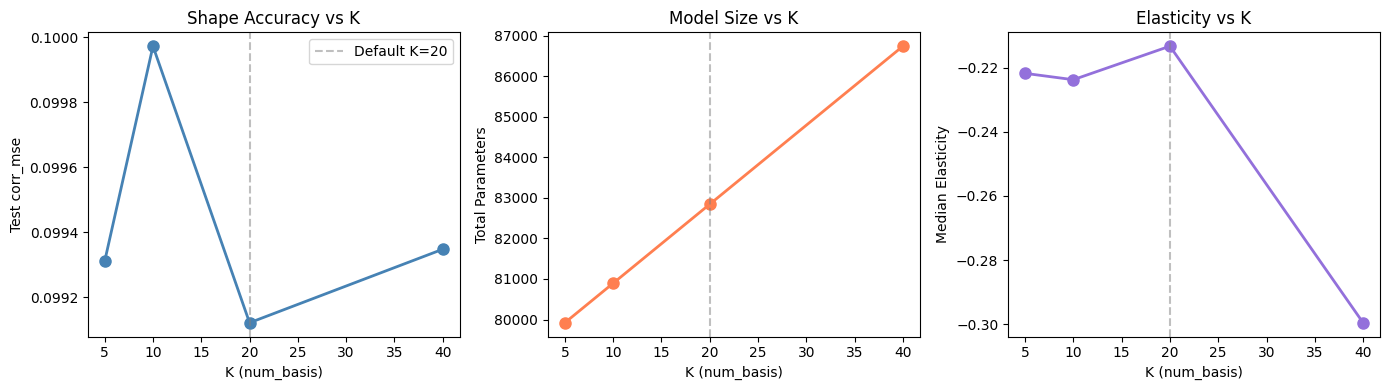

Saved figure to docs/figures/k_sensitivity.png


In [15]:
# B3 Visualization: K sensitivity
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# corr_mse vs K
ax = axes[0]
ax.plot(k_df['K'], k_df['test_corr_mse'], 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='Default K=20')
ax.set_xlabel('K (num_basis)')
ax.set_ylabel('Test corr_mse')
ax.set_title('Shape Accuracy vs K')
ax.legend()

# n_params vs K
ax = axes[1]
ax.plot(k_df['K'], k_df['n_params'], 'o-', color='coral', linewidth=2, markersize=8)
ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('K (num_basis)')
ax.set_ylabel('Total Parameters')
ax.set_title('Model Size vs K')

# median elasticity vs K
ax = axes[2]
ax.plot(k_df['K'], k_df['median_elasticity'], 'o-', color='mediumpurple', linewidth=2, markersize=8)
ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('K (num_basis)')
ax.set_ylabel('Median Elasticity')
ax.set_title('Elasticity vs K')

plt.tight_layout()
plt.savefig('../docs/figures/k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to docs/figures/k_sensitivity.png")

## B4: Computational Cost Comparison

Compare wall-clock training times across all model types.
NN times from B2 multi-seed runs. Baseline times measured here.

In [16]:
# B4: Computational cost comparison
from sklearn.linear_model import LinearRegression, Ridge

# --- Per-product log-log ---
t0 = time.time()
for pid in train_df['product_id'].unique():
    mask = train_df['product_id'] == pid
    sub = train_df.loc[mask]
    if len(sub) < 2 or sub['log_r'].nunique() < 2:
        continue
    lr = LinearRegression()
    lr.fit(sub[['log_r']].values, sub['y'].values)
t_perproduct = time.time() - t0
print(f"Per-product log-log: {t_perproduct:.3f}s")

# --- Pooled log-log ---
t0 = time.time()
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(train_df[['log_r']].values, train_df['y'].values)
t_pooled = time.time() - t0
print(f"Pooled log-log: {t_pooled:.3f}s")

# --- Pooled log-log + FE ---
t0 = time.time()
train_means = train_df.groupby('product_id')[['log_r', 'y']].transform('mean')
X_fe = train_df[['log_r']].values - train_means[['log_r']].values
y_fe = train_df['y'].values - train_means['y'].values
fe_model = Ridge(alpha=1.0, random_state=42)
fe_model.fit(X_fe, y_fe)
t_fe = time.time() - t0
print(f"Pooled log-log + FE: {t_fe:.3f}s")

# --- XGBoost ---
import xgboost as xgb
ALL_FEATURES_XGB_t = ['log_r'] + CONTEXT_FEATURES + PRODUCT_FEATURES + REVIEW_FEATURES
X_train_t = train_df[ALL_FEATURES_XGB_t].values
y_train_t = train_df['y'].values
X_val_t = val_df[ALL_FEATURES_XGB_t].values
y_val_t = val_df['y'].values

dtrain_t = xgb.DMatrix(X_train_t, label=y_train_t, feature_names=ALL_FEATURES_XGB_t)
dval_t = xgb.DMatrix(X_val_t, label=y_val_t, feature_names=ALL_FEATURES_XGB_t)

xgb_params_t = {
    "objective": "reg:squarederror",
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "seed": 42
}

t0 = time.time()
bst = xgb.train(xgb_params_t, dtrain_t, num_boost_round=500,
                evals=[(dval_t, "val")], early_stopping_rounds=50, verbose_eval=False)
t_xgb = time.time() - t0
print(f"XGBoost ({bst.best_iteration} rounds): {t_xgb:.3f}s")

# --- NN timing from multi-seed ---
nn_times = pd.read_csv(TABLES_DIR / 'multi_seed_results.csv')['train_time_s']
nn_mean = nn_times.mean()
nn_std = nn_times.std()
nn_epochs = pd.read_csv(TABLES_DIR / 'multi_seed_results.csv')['n_epochs']

print(f"\nTwo-Head NN: {nn_mean:.1f} ± {nn_std:.1f}s (mean ± std, 5 seeds, {nn_epochs.min()}-{nn_epochs.max()} epochs)")

# Summary table
timing_data = pd.DataFrame({
    'Model': ['Per-product log-log', 'Pooled log-log', 'Pooled log-log + FE', 
              'XGBoost', 'Two-Head NN'],
    'Training_Time_s': [t_perproduct, t_pooled, t_fe, t_xgb, nn_mean],
    'Notes': [f'{len(train_df["product_id"].unique())} separate OLS', 
              'Single Ridge', 'Demeaning + Ridge',
              f'{bst.best_iteration} rounds',
              f'Mean of 5 seeds, {int(nn_epochs.mean())} epochs avg']
})

print("\n\nB4 COMPUTATIONAL COST COMPARISON")
print("=" * 70)
print(timing_data.to_string(index=False))

timing_data.to_csv(TABLES_DIR / 'timing_comparison.csv', index=False)
print(f"\nSaved to {TABLES_DIR / 'timing_comparison.csv'}")

Per-product log-log: 0.733s
Pooled log-log: 0.005s
Pooled log-log + FE: 0.014s
XGBoost (74 rounds): 0.156s



Two-Head NN: 36.5 ± 7.1s (mean ± std, 5 seeds, 60-105 epochs)


B4 COMPUTATIONAL COST COMPARISON
              Model  Training_Time_s                          Notes
Per-product log-log         0.732675              1218 separate OLS
     Pooled log-log         0.005357                   Single Ridge
Pooled log-log + FE         0.013621              Demeaning + Ridge
            XGBoost         0.155968                      74 rounds
        Two-Head NN        36.486939 Mean of 5 seeds, 82 epochs avg

Saved to ../tables/timing_comparison.csv
